This notebook replicates the PRehab adaptation algorithm by breaking it down into various steps. I have tried to replicate as much of the steps as they have mentioned in the paper, based on the equations and methods used. <b>Note:</b> parts of the algorithm where the paper has not fully elaborated on, I have taken assistance from LLMs to get the code logically correct.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional,Dict
import math
import random

## Helper Functions and Ability Zone Creation

In [14]:
# -------------------------------------------------------
# Step 0: plotting helpers
# -------------------------------------------------------
# Contains function blocks that we will used to visualize the game parameters and certain steps


def plot_ability_zone(ability, title="Ability zone", ax=None):
    """Show the ability matrix as a heatmap."""
    if ax is None:
        fig, ax = plt.subplots()
    im = ax.imshow(ability, cmap="Blues", origin="lower")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)


def plot_edge_and_mask(ability, edge, mask, title_prefix=""):
    """Side‑by‑side plots: ability heatmap, edge, and mask."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    plot_ability_zone(ability, title_prefix + "Ability", ax=axes[0])
    axes[1].imshow(edge, cmap="gray", origin="lower")
    axes[1].set_title(title_prefix + "Edge (Sobel magnitude)")
    axes[2].imshow(mask, cmap="gray", origin="lower")
    axes[2].set_title(title_prefix + "Mask (challenge areas)")
    plt.tight_layout()


def plot_targets_on_grid(ability, targets, start, title="Targets"):
    """Overlay targets on top of the ability zone."""
    fig, ax = plt.subplots()
    plot_ability_zone(ability, title, ax=ax)
    if len(targets) > 0:
        ys, xs = zip(*targets)
        ax.scatter(xs, ys, c='red', s=40, label="targets")
    ax.scatter([start[1]], [start[0]], c='yellow', s=80, edgecolors="black", label="start")
    ax.legend()
    plt.tight_layout()


In [15]:
# -------------------------------------------------------
# Step 1: Build a toy ability zone
# Three ways to do this:
# 1. Make the zone using a noisy distance based gradient that spreads from the center of the screen
# 2. Make the zone using a noisy exponential decay based gradient from the center (Dipshika's version)
# 3. Make the zone using a linear decay based gradient from the center (Simplest version)
# -------------------------------------------------------

def make_toy_ability_zone(size=15, center=None, noise=0.05):
    """
    Create a simple 'ability zone':
    - High values near the center (start position),
    - Gradually decreasing towards the edges,
    - Plus some noise.
    """
    if center is None:
        center = (size // 2, size // 2)

    cy, cx = center
    y, x = np.indices((size, size))
    dist = np.sqrt((y - cy)**2 + (x - cx)**2) #calculates Euclidean distance from the center 

    # Normalize distance 0..1, then invert so center is high ability.
    dist_norm = dist / dist.max()
    ability = 1.0 - dist_norm

    # Add small random noise, then clip to [0, 1]
    ability += noise * np.random.randn(size, size)
    ability = np.clip(ability, 0.0, 1.0)
    return ability, center


#dipsikha's version of ability zone
def generate_synthetic_ability_zone(grid_size=50):
    cx, cy = grid_size // 2, grid_size // 2
    center = (cx,cy)
    x, y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    zone = np.exp(-0.01 * ((x - cx)**2 + (y - cy)**2))
    zone_norm = zone / zone.max()
    #ability = 1.0 - dist_norm
    zone_norm += 0.05 * np.random.rand(grid_size, grid_size) #added noise here
    return zone, center


def make_decay_based_ability_zone(size):
    ability = np.zeros((size, size))
    cy, cx = size//2, size//2
    center = (cx,cy)
    for r in range(size):
        for c in range(size):
            d = math.dist((cy,cx),(r,c))
            ability[r,c] = max(0, 1 - d/6) #linear decay
    return ability, center

This code creates the ability zone by defining a set of matrices with a center and the overall size of the matrix. Distance values are calculated using the Euclidean distance, this is followed by normalizing them between 0 and 1. Then ability values are calculated as the inverse of that distance values. Finally, random noise is added to it.

## Making Algorithm 1

In [16]:
# -------------------------------------------------------
# Step 2: Algorithm 1 – from ability zone to mask & difficulty modes
# -------------------------------------------------------
# Provides functions that convert the ability zone into an image, apply edge detection and detect masks.
#Finally, it creates a set of mappings between difficulty modes and the areas of the ability zone that fit with that mode

def sobel_edge_magnitude(image):
    """
    Very simple Sobel implementation using convolution kernels, as in the paper.
    """
    #kx,ky are kernels that will be used with the main matrix to perform convolution
    kx = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=float)
    ky = np.array([[1,  2,  1],
                   [0,  0,  0],
                   [-1, -2, -1]], dtype=float)

    # Pad to handle borders
    padded = np.pad(image, 1, mode='edge')
    gx = np.zeros_like(image)
    gy = np.zeros_like(image)

    # Convolution
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+3, j:j+3]
            gx[i, j] = np.sum(region * kx)
            gy[i, j] = np.sum(region * ky)

    grad = np.sqrt(gx**2 + gy**2)
    # Normalize to [0, 1] for convenience
    grad /= grad.max() if grad.max() > 0 else 1.0
    return grad


def make_mask_from_edge(edge, threshold=0.4):
    """
    Mask = True where gradient magnitude is above threshold.
    This corresponds to challenge areas near the 'ability frontier'.
    The threshold value is currently set arbitrarily but will need to be changed later.
    """
    return edge >= threshold

Difficulty Mode definitions
    ---------------- <br>

    EASY       : cells INSIDE the edge
                 -> mask=False  AND  dist_from_start < mean_edge_dist
                 These are well-known, comfortable positions.

    MEDIUM     : cells ON the edge
                 -> mask=True
                 These lie exactly on the patient's current movement frontier.
                 Best for constructive challenge: hard enough to require effort,
                 close enough to be achievable.

    DIFFICULT  : cells OUTSIDE the edge
                 -> mask=False  AND  dist_from_start > mean_edge_dist
                 These are genuinely beyond the current ability zone.
                 Used for patients who are recovering quickly.

In [17]:
#use a three difficulty mode
def select_cells_3mode(mask: np.ndarray,
                        mode: str,
                        start: Tuple[int, int]) -> List[Tuple[int, int]]:
    """
    3-mode difficulty selector tied to the Sobel edge mask.

    Parameters
    ----------
    mask  : bool array (h x w) from make_mask_from_edge()
    mode  : one of 'easy' | 'medium' | 'difficult'
    start : (row, col) of the patient's hand start 
    

    Returns
    -------
    List of (row, col) tuples that are valid target positions for this mode.
    
    """
    h, w_grid = mask.shape
    sy, sx = start

    all_cells = [(y, x) for y in range(h) for x in range(w_grid)]

    # The frontier radius: average distance from start to all edge cells.
    # Acts as a scalar "radius" separating inside from outside.
    edge_cells = [(y, x) for (y, x) in all_cells if mask[y, x]]
    if edge_cells:
        mean_edge_dist = np.mean([math.dist((sy, sx), c) for c in edge_cells]) #acts like a threshold
    else:
        mean_edge_dist = h / 2.0   # safe fallback if mask is empty

    if mode == "easy":
        # Inside: not on edge, closer than the frontier
        # checks if the cell locations are < mead_edge_dist AND not part of the mask
        return [(y, x) for (y, x) in all_cells
                if not mask[y, x]
                and math.dist((sy, sx), (y, x)) < mean_edge_dist]

    if mode == "medium":
        # Exactly on the Sobel edge
        return edge_cells

    if mode == "difficult":
        # Outside: not on edge, farther than the frontier
        return [(y, x) for (y, x) in all_cells
                if not mask[y, x]
                and math.dist((sy, sx), (y, x)) > mean_edge_dist]

    raise ValueError(f"Unknown mode '{mode}'. Choose: easy | medium | difficult") #Error check to see if any other mode has been put in


The above code provides a simple logic for 3 difficulty modes instead of 5 in the paper. This makes the division of difficulty easier for testing purposes.

In [18]:
#Implement Algorithm 1 from the paper
def algorithm1_generate_pointing_tasks(ability, start, threshold=0.4):
    """
    Very direct version of Algorithm 1:
    1. Compute edge (Sobel),
    2. Compute mask,
    3. For each mode, list candidate cells.
    """
    edge = sobel_edge_magnitude(ability)
    mask = make_mask_from_edge(edge, threshold=threshold)

    modes = ["easy", "medium", "difficult"]
    S = {}
    for m in modes:
        Cm = select_cells_3mode(mask, m, start) #the list of cells belonging to each difficulty mode
        # In the paper, Algorithm 2 filters / orders Cm.
        # Here we simply store Cm as "all possible target cells" for that mode.
        S[m] = Cm

    return S, edge, mask


## Making Algorithm 2

In [19]:
# -------------------------------------------------------
# Step 3: Reward function used by Algorithm 2
# -------------------------------------------------------
#Make a reward function that applies to each child node in the MCTS 
def compute_reward_for_child(child_pos, sibling_positions, start,
                             alpha=0.7, beta=0.3):
    """
    Reward R_j = 0.5 * (alpha * distance_j + beta * shift_j)
    where each component is normalized to [0, 1].
    Two parameters are crucial here
    - distance_j or Usefulness: how far from start node is compared to its sibling nodes
    - shift_j   : how 'left' is the current cell compared to its siblings (for variety)
    """
    cy, cx = start

    # distances among sibling nodes
    dists = [math.dist((cy, cx), (y, x)) for (y, x) in sibling_positions]
    max_dist = max(dists) if dists else 1.0

    yj, xj = child_pos #current node's position
    dj = math.dist((cy, cx), (yj, xj))
    distance_j = dj / max_dist if max_dist > 0 else 0.0

    # "shift": encourage spread to the left – normalize by width of grid
    xs = [x for (_, x) in sibling_positions]
    max_x = max(xs) if xs else 1.0
    min_x = min(xs) if xs else 0.0
    spread = max_x - min_x if max_x != min_x else 1.0
    shift_j = (max_x - xj) / spread  # 1 if far left, 0 if far right

    R_j = 0.5*(alpha * distance_j + beta * shift_j)
    return R_j


The Monte Carlo Tree Search (MCTS) procedure relies on four steps: <br>
1. Selection: selecting existing nodes based on their Upper Confidence bounds for Trees (UCT) value. <br>
2. Expansion: adding new nodes, given we have target candidates left for the selected difficulty mode. <br>
3. Simulation: simulating the target sequences for a difficulty mode such that each target maximizes overall reward. <br>
4. Backpropagation: updating each node's reward values based on how many times have they been visited in the simulation. <br>

From this procedure, the best order of target locations for a given difficulty level are provided such that they can lead to maximum improvement (AKA reward) for the patient.

In [20]:
# -------------------------------------------------------
# Step 4: MCTS / Algorithm 2 – tree search with UCT
# -------------------------------------------------------

@dataclass
class MCTSNode:
    #initialize the tree structure using these values
    position: Tuple[int, int]       # Which grid cell (target) this node represents
    parent: Optional["MCTSNode"]    # The previous node in the sequence — None only for the root
    children: List["MCTSNode"] = field(default_factory=list) # The nodes that were selected after this one
    visits: int = 0 # How many times has this node been visited
    total_reward: float = 0.0 # Sum of all rewards from simulations passing through this node

    def add_child(self, child_pos) -> "MCTSNode": #performs expansion operation
        child = MCTSNode(position=child_pos, parent=self)
        self.children.append(child)
        return child
    # Example: if a node represents "we selected target A first", then
    # calling add_child((3,9)) expands a branch meaning "...and then we placed target at (3,9) location."

    #the below code ensures this function is an attribute of each node, 
    # so node.mean_reward() tells us the mean reward for that node
    @property
    def mean_reward(self):
        return self.total_reward / self.visits if self.visits > 0 else 0.0

    def is_root(self): #this function checks if the current node is the root node or not
        return self.parent is None


def uct_value(child: MCTSNode): 
    """
    UCT formula: V_j = R_j + sqrt(2 * log(n) / n_j)
    where:
    - R_j = average reward at child
    - n   = visits to parent
    - n_j = visits to child
    """
    if child.visits == 0 or child.parent is None:
        return float("inf")  # ensure every child is tried at least once

    R_j = child.mean_reward   #exploitation term: how good this target has been on average in past simulations.
    n = child.parent.visits   # how many times the parent has been visited. This grows with every iteration.
    n_j = child.visits        # how many times this child specifically has been visited.
    exploration = math.sqrt(2 * math.log(n) / n_j)
    return R_j + exploration


def tree_policy_select(node: MCTSNode): #Selection step
    """
    Move down the tree by always picking the child with highest UCT value
    until reaching a leaf.
    """
    current = node
    while current.children:
        current = max(current.children, key=lambda c: uct_value(c))
    return current


def expand(node: MCTSNode, remaining_candidates, chosen_positions, start,
           alpha, beta): #Expansion step
    """
    Add children for some of the remaining candidate targets.
    For teaching, we'll add all remaining candidates as children once.
    """
    if not remaining_candidates:
        return node  # no expansion possible

    siblings = remaining_candidates
    for pos in remaining_candidates:
        # reward for this child if we choose it next
        R_j = compute_reward_for_child(pos, siblings, start, alpha, beta)
        child = node.add_child(pos)
        # store reward as if this node's "immediate reward" were R_j
        child.total_reward += R_j
        child.visits += 1
    return random.choice(node.children)

def default_policy_rollout(node: MCTSNode, all_candidates, level_length,
                           chosen_positions, start, alpha, beta): #Simulation step
    """
    Simulate a full level by randomly choosing remaining targets.
    Reward = average of R_j over the sequence.
    """
    remaining = [c for c in all_candidates if c not in chosen_positions]
    sequence = []
    rewards = []

    current_start = start
    siblings = remaining.copy()

    while remaining and len(sequence) + len(chosen_positions) < level_length:
        pos = random.choice(remaining) #Monte Carlo step: just random sampling of a target location
        remaining.remove(pos)
        sequence.append(pos)

        R_j = compute_reward_for_child(
            pos, siblings, current_start, alpha, beta
        )
        rewards.append(R_j)
        current_start = pos

    if not rewards:
        return 0.0, sequence
    return sum(rewards) / len(rewards), sequence


def backup(node: MCTSNode, reward: float): #backpropagation step
    """
    Propagate reward up the tree.
    """
    current = node
    while current is not None:
        current.visits += 1
        current.total_reward += reward
        current = current.parent


the above code implements the entire MCTS sequence through various functions.

In [21]:
def extract_best_sequence(root: MCTSNode):
    """
    Follow the best child (highest mean reward) from the root downward
    to form the final recommended sequence.
    """
    sequence = []
    current = root
    while current.children:
        current = max(current.children, key=lambda c: c.mean_reward)
        sequence.append(current.position)
    return sequence


def algorithm2_tree_generation(candidates, start,
                               level_length=8,
                               iterations=300,
                               alpha=0.7,
                               beta=0.3):
    """
    Main driver for Algorithm 2:
    - candidates: list of target positions for ONE difficulty mode (P_m)
    - start: start position
    - level_length: how many targets in the level
    - iterations: MCTS iterations (budget)
    - alpha, beta: parameters for UCT & reward
    """
    # Root node uses a "virtual" starting position (same as start)
    root = MCTSNode(position=start, parent=None)

    if not candidates:
        return [], root

    for it in range(iterations):
        # 1. Selection
        leaf = tree_policy_select(root)

        # Determine which targets are already chosen along this path
        path_positions = []
        node = leaf
        while not node.is_root():
            path_positions.append(node.position)
            node = node.parent
        path_positions = list(reversed(path_positions))

        # 2. Expansion (if we still have room for more targets)
        if len(path_positions) < level_length:
            remaining = [c for c in candidates if c not in path_positions]
            if remaining:
                leaf = expand(leaf, remaining, path_positions, start, alpha, beta)

        # 3. Simulation
        # Recompute chosen_positions for this new leaf
        chosen_positions = []
        node = leaf
        while not node.is_root():
            chosen_positions.append(node.position)
            node = node.parent
        chosen_positions = list(reversed(chosen_positions))

        reward, rollout_sequence = default_policy_rollout(
            leaf, candidates, level_length, chosen_positions,
            start, alpha, beta
        )

        # 4. Backpropagation
        backup(leaf, reward)

    best_sequence = extract_best_sequence(root)
    return best_sequence, root

The above code outputs the best sequence of target locations for a particular difficulty level and defined by a particular patient's ability zone profile.

In [22]:
# -------------------------------------------------------
# Step 5: Putting it together – experiments & visualizations
# -------------------------------------------------------

def run_demo(
    size=15,
    threshold=0.4,
    mode="difficult",
    level_length=8,
    iterations=300,
    alpha_beta_pairs=((0.7, 0.3), (0.5, 0.5), (0.3, 0.7))
):
    """
    High‑level demo:
    1. Build an ability zone
    2. Run Algorithm 1
    3. For one mode, run Algorithm 2 with different parameter settings
    4. Visualize ability, mask, candidates, best sequences
    """
    ability, start = make_decay_based_ability_zone(size) #change type of ability zone algorithm here
    S, edge, mask = algorithm1_generate_pointing_tasks(
        ability, start, threshold=threshold
    )

    # Visualize ability, edge and mask
    plot_edge_and_mask(ability, edge, mask,
                       title_prefix=f"(t={threshold}) ")

    candidates = S[mode]
    print(f"Mode '{mode}' has {len(candidates)} candidate targets.")

    plot_targets_on_grid(ability, candidates, start,
                         title=f"Candidates for mode '{mode}'")

    # Try different parameter combinations
    for (alpha, beta) in alpha_beta_pairs:
        print(f"\nRunning MCTS for mode='{mode}', alpha={alpha}, beta={beta}")
        best_seq, root = algorithm2_tree_generation(
            candidates, start,
            level_length=level_length,
            iterations=iterations,
            alpha=alpha,
            beta=beta
        )
        print("Best sequence length:", len(best_seq))

You can change how the ability zone is made by changing the function in the above cell on line 20.

We can now run a demo version that outputs the ability zone image, its edges, the corresponding masks and the best target locations for given difficulty model input

Mode 'difficult' has 116 candidate targets.

Running MCTS for mode='difficult', alpha=0.7, beta=0.3
Best sequence length: 3

Running MCTS for mode='difficult', alpha=0.5, beta=0.5
Best sequence length: 3


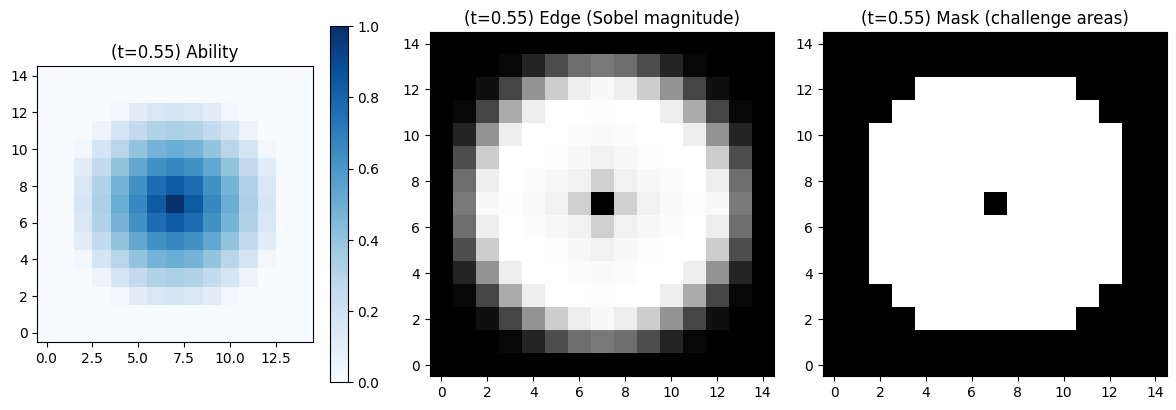

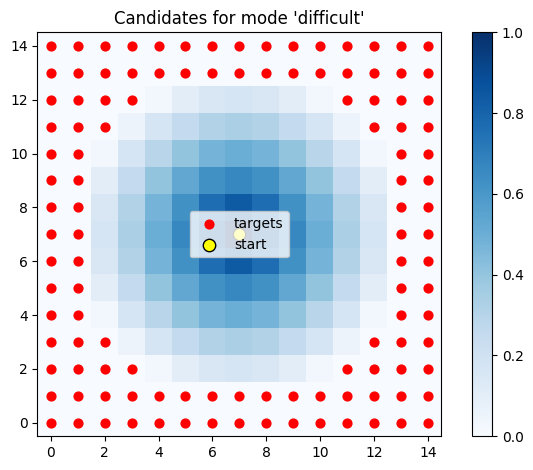

In [23]:
# -------------------------------------------------------
# Try this out
# -------------------------------------------------------
if __name__ == "__main__":
    run_demo(
        size=15,
        threshold=0.55,
        mode="difficult",
        level_length=4,
        iterations=300,
        alpha_beta_pairs=((0.7, 0.3), (0.5, 0.5))
    )
    plt.show()


difficulty adjustment algorithm as per the paper.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

MODES    = ["easy", "medium", "difficult"]
MODE_IDX = {"easy": 0, "medium": 1, "difficult": 2}


# ─────────────────────────────────────────────────────────────────────────────
# CORE FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def difficulty_adjustment_session(
        sequences,
        start_mode= "medium",
        w= 1,
        n_trials= 30,
        success_prob= None,
        seed= 42):
    """
    Simulate one therapy session with dynamic difficulty adjustment.

    Parameters
    ----------
    sequences     : dict mapping mode -> ordered list of (row, col) targets
                    pre-computed by Algorithm 2 / MCTS
    start_mode    : difficulty the player starts in ("easy"|"medium"|"difficult")
    w             : window size — consecutive successes OR failures needed
                    to step difficulty up or down by one level
    n_trials      : total number of pointing tasks in the session
    success_prob  : per-mode Bernoulli success probability dict
                    default: easy=0.85, medium=0.55, difficult=0.30
    seed          : RNG seed for reproducibility

    Returns
    -------
    List of plain dicts, one per trial, with keys:
        trial_num     : int   – 1-indexed trial counter
        mode          : str   – difficulty mode DURING this trial
        target        : tuple – (row, col) target position shown
        success       : bool  – whether the player succeeded
        consec_wins   : int   – consecutive wins AT TIME OF LOGGING
        consec_losses : int   – consecutive losses AT TIME OF LOGGING
        mode_changed  : bool  – True if a transition fired after this trial
        change_reason : str   – "w consec win(s)" | "w consec loss(es)" | ""

    Transition logic
    ----------------
    Each trial:
      1. Present next target in current mode's sequence
         (cycles back via modulo if sequence is exhausted)
      2. Simulate success/failure via Bernoulli(success_prob[mode])
      3. Update consecutive counters:
           success -> consec_wins += 1,   reset consec_losses = 0
           failure -> consec_losses += 1, reset consec_wins   = 0
      4. Check for mode transition:
           consec_wins   >= w AND mode != "difficult" -> step difficulty UP
           consec_losses >= w AND mode != "easy"      -> step difficulty DOWN
         On any transition: reset both counters to 0.
    """
    random.seed(seed)

    if success_prob is None:
        success_prob = {"easy": 0.85, "medium": 0.55, "difficult": 0.30}

    # Per-mode position pointers — track which target to show next
    cursors= {"easy": 0, "medium": 0, "difficult": 0}

    current_mode= start_mode
    consec_wins= 0
    consec_losses= 0

    log= []

    for t in range(1, n_trials + 1):

        # ── Step 1: Pick the next target in the current mode's sequence ──────
        seq = sequences[current_mode]
        target= seq[cursors[current_mode] % len(seq)]
        cursors[current_mode] += 1

        # ── Step 2: Simulate outcome ──────────────────────────────────────────
        success= random.random() < success_prob[current_mode]

        # ── Step 3: Update consecutive counters ───────────────────────────────
        if success:
            consec_wins  += 1
            consec_losses = 0
        else:
            consec_losses += 1
            consec_wins   = 0

        # ── Step 4: Check mode transition ─────────────────────────────────────
        mode_changed= False
        change_reason= ""
        prev_mode= current_mode

        if consec_wins >= w and MODE_IDX[current_mode] < 2:
            current_mode  = MODES[MODE_IDX[prev_mode] + 1]
            consec_wins   = 0
            consec_losses = 0
            mode_changed  = True
            change_reason = f"{w} consec win(s)"

        elif consec_losses >= w and MODE_IDX[current_mode] > 0:
            current_mode  = MODES[MODE_IDX[prev_mode] - 1]
            consec_losses = 0
            consec_wins   = 0
            mode_changed  = True
            change_reason = f"{w} consec loss(es)"

        # ── Log this trial as a plain dict ────────────────────────────────────
        log.append({
            "trial_num":     t,
            "mode":          prev_mode,            # mode DURING this trial
            "target":        target,
            "success":       success,
            "consec_wins":   consec_wins  if not mode_changed else w,
            "consec_losses": consec_losses if not mode_changed else w,
            "mode_changed":  mode_changed,
            "change_reason": change_reason,
        })

    return log


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: pretty-print a session log
# ─────────────────────────────────────────────────────────────────────────────

def print_session_log(log: List[Dict]) -> None:
    """Print a compact human-readable summary of the session."""
    header = f"{'Trial':>6}  {'Mode':>10}  {'Target':>10}  {'Result':>8}  " \
             f"{'cWins':>6}  {'cLoss':>6}  {'Changed':>8}  Reason"
    print(header)
    print("-" * len(header))
    for r in log:
        result   = "WIN " if r["success"] else "LOSS"
        changed  = "YES" if r["mode_changed"] else "-"
        reason   = r["change_reason"] if r["change_reason"] else "-"
        print(f"{r['trial_num']:>6}  {r['mode']:>10}  "
              f"{str(r['target']):>10}  {result:>8}  "
              f"{r['consec_wins']:>6}  {r['consec_losses']:>6}  "
              f"{changed:>8}  {reason}")


# ─────────────────────────────────────────────────────────────────────────────
# QUICK DEMO
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Dummy sequences — replace with real MCTS output from algorithm2_sequence()
    dummy_sequences: Dict[str, List[Tuple[int, int]]] = {
        "easy":      [(5,5),(4,6),(6,4),(5,7),(7,5),(4,5),(5,4),(6,5)],
        "medium":    [(3,3),(3,9),(9,3),(9,9),(5,2),(2,5),(8,5),(5,8)],
        "difficult": [(1,1),(1,11),(11,1),(11,11),(0,7),(7,0),(14,7),(7,14)],
    }

    for w in [1, 2, 3]:
        print(f"\n{'='*60}")
        print(f"  w = {w}  (need {w} consecutive wins/losses to change mode)")
        print(f"{'='*60}")

        log = difficulty_adjustment_session(
            sequences   = dummy_sequences,
            start_mode  = "medium",
            w           = w,
            n_trials    = 20,
            success_prob= {"easy": 0.85, "medium": 0.55, "difficult": 0.30},
            seed        = 42
        )

        print_session_log(log)



  w = 1  (need 1 consecutive wins/losses to change mode)
 Trial        Mode      Target    Result   cWins   cLoss   Changed  Reason
--------------------------------------------------------------------------
     1      medium      (3, 3)      LOSS       1       1       YES  1 consec loss(es)
     2        easy      (5, 5)      WIN        1       1       YES  1 consec win(s)
     3      medium      (3, 9)      WIN        1       1       YES  1 consec win(s)
     4   difficult      (1, 1)      WIN        1       0         -  -
     5   difficult     (1, 11)      LOSS       1       1       YES  1 consec loss(es)
     6      medium      (9, 3)      LOSS       1       1       YES  1 consec loss(es)
     7        easy      (4, 6)      LOSS       0       1         -  -
     8        easy      (6, 4)      WIN        1       1       YES  1 consec win(s)
     9      medium      (9, 9)      WIN        1       1       YES  1 consec win(s)
    10   difficult     (11, 1)      WIN        1       0  

## Data Ingestion Layer

the above code simulates a patient with three versions of the difficulty adjustment parameter where the player's difficulty mode increases/decreases after 1 or 2 or 3 consecutive wins/losses on the current difficulty mode